# Classifier Threshold Tuning

Learning objectives:

1. Distinguish cases where one should trade Recall for Precision and vice-versa
2. Identify the component that affects this trade-off in a fitted classifier (it is the classification threshold)
3. Given a classifier; tune the decision threshold to maximize either precision or recall
4. Given a classifier and a specific ratio between $FN$ and $FP$; tune the decision threshold to optimize for that ratio

## Importance of Tuning the Classification Threshold

In medical screening, such as tumor detection, the **cost of a False Negative** (missed cancer) is significantly higher than the **cost of a False Positive** (unnecessary follow-up tests).

- **Priority:** Maximize **Recall** (Sensitivity) to identify all true positive cases.
- **Trade-off:** Lower **Precision** is accepted as a necessary consequence of minimizing misses.    
- **Strategy:** The **decision threshold** is shifted below $0.5$. By lowering the probability required to trigger a "positive" classification, the model becomes more inclusive, capturing more cases at the expense of more false alarms.

In this notebook we show how to use the [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html#sklearn.model_selection.TunedThresholdClassifierCV "sklearn.model_selection.TunedThresholdClassifierCV") to tune the decision threshold, depending on a metric of interest.

## The diabetes dataset

- Used to illustrate tuning the decision threshold.
- Available on OpenML: [https://www.openml.org/d/37](https://www.openml.org/d/37).
- Fetched via [`fetch_openml`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html#sklearn.datasets.fetch_openml "sklearn.datasets.fetch_openml").

In [1]:
from sklearn.datasets import fetch_openml

diabetes = fetch_openml(data_id=37, as_frame=True, parser="pandas")
data, target = diabetes.data, diabetes.target

- Inspect the target to see what kind of problem we have.

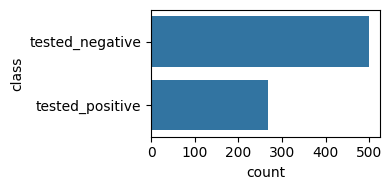

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(4, 2))
sns.countplot(y=target)
plt.xticks(np.arange(0, target.value_counts().max() + 100, 100))
plt.tight_layout()

- Slight class imbalance: about twice as many negative as positive samples.
- Keep this in mind when interpreting evaluation results.



Also: Labels are not 0/1: let's convert:

- **"tested_negative"** as the negative class
- **"tested_positive"** as the positive class

In [3]:
pos_label = 'tested_positive'
neg_label = 'tested_negative'

In [4]:
# The target contains 'tested_positive' and 'tested_negative'.
# We map 'tested_positive' to 1 (the class where False Negatives occur).
y = (target == 'tested_positive').astype(int)

Split the data safely to prevent data leakage during threshold tuning:

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, y,
    stratify=y,
    test_size=0.3,
    random_state=42,
)

## Our vanilla classifier

- Basic model: scaler + logistic regression.
- The `"balanced"` mode uses the values of `y` to automatically adjust weights inversely proportional to class frequencies. That is; it adjusts the training model for the imbalance in the data.
  - Some models like `LogisticRegression` have it.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(class_weight="balanced")),
    ]
)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

We evaluate the model with cross-validation using **accuracy**:

In [7]:
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate

scoring = ["accuracy", "precision", "recall"]

cv_results_vanilla_model = pd.DataFrame(
    cross_validate(
        model,
        X_train,
        y_train,
        scoring=scoring,
        cv=StratifiedKFold(
            n_splits=5,
            random_state=42,
            shuffle=True,
        ),
        return_train_score=True,
        return_estimator=True,
    )
)

In [8]:
cv_scores = ["test_" + s for s in scoring]
cv_results_vanilla_model[cv_scores].agg(["mean", "std"]).T

,mean,std
test_accuracy,0.744981,0.034247
test_precision,0.616460,0.045847
test_recall,0.717070,0.058599


- These are estimates for one classification threshold of 0.5 (default).
- Our predictive model succeeds to grasp the relationship between the data and the target.
- Training and testing scores are close → no overfitting.

## Tuning the decision threshold

[`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html#sklearn.model_selection.TunedThresholdClassifierCV "sklearn.model_selection.TunedThresholdClassifierCV") **meta-estimator**: tune the decision threshold for a chosen metric.

Remember that:

- **Precision** is proportional to the threshold; the higher the threshold, the less the False Positives (`FP`).
- **Recall** is inversely proportional to the threshold; the lower the threshold, the lower the False Negatives (`FN`).

In [9]:
from sklearn.model_selection import TunedThresholdClassifierCV

tuned_model = TunedThresholdClassifierCV(
    estimator=model,
    scoring='recall',
    cv=StratifiedKFold(
        n_splits=3,
        random_state=42,
        shuffle=True,
    )
)

scoring = ["accuracy", "precision", "recall"]

cv_results_tuned_model = pd.DataFrame(
    cross_validate(
        tuned_model,
        X_train,
        y_train,
        scoring=scoring,
        cv=StratifiedKFold(
            n_splits=5,
            random_state=42,
            shuffle=True,
        ),
        return_train_score=True,
        return_estimator=True,
    )
)

In [10]:
cv_scores = ["test_" + s for s in scoring]
cv_results_tuned_model[cv_scores].agg(["mean", "std"]).T

,mean,std
test_accuracy,0.350069,0.006707
test_precision,0.348875,0.004376
test_recall,1.000000,0.000000


- In comparison with the vanilla model, we observe that the precision score increased. Of course, it comes at the cost of a lower recall score.
- It means that our model is now more sensitive to the positive class but makes more mistakes on the negative class.

It is important to note that this tuned predictive model is internally the same model as the vanilla model: **they have the same fitted coefficients**.


<Axes: >

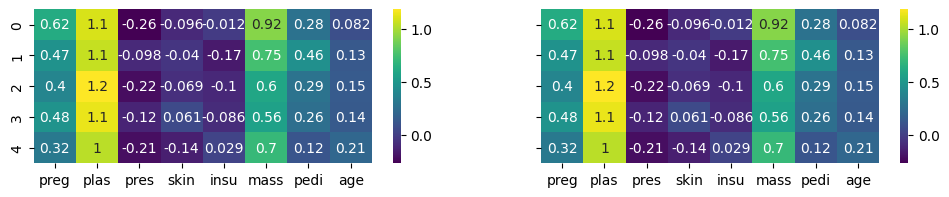

In [11]:
#|code-fold: true

# vanilla model coefficients
fig, axes = plt.subplots(ncols=2, figsize=(12, 2), sharex=True, sharey=True)

sns.heatmap(
    pd.DataFrame(
        [est[-1].coef_.ravel() for est in cv_results_vanilla_model["estimator"]],
        columns=diabetes.feature_names,
    ),
    annot=True,
    cmap="viridis",
    ax=axes[0],
)

# tuned model coefficients
sns.heatmap(
    pd.DataFrame(
        [est.estimator_[-1].coef_.ravel() for est in cv_results_tuned_model["estimator"]],
        columns=diabetes.feature_names,
    ),
    annot=True,
    cmap="viridis",
    ax=axes[1],
)

Both plots show the same values. **Only the decision threshold of each model was changed during the cross-validation**.

Let's see what **threshold** did out meta-estimator learn?

In [12]:
threshold = pd.Series([est.best_threshold_ for est in cv_results_tuned_model["estimator"]])
threshold

0    0.004346
1    0.004122
2    0.003505
3    0.003246
4    0.005111
dtype: float64

In [13]:
print(threshold.mean().round(3))

0.004


On average, a decision threshold around 0.004 maximizes the recall, which is different from the default decision threshold of 0.5.

Thus tuning the decision threshold is particularly important when the output of the predictive model is used to make decisions. This is nice to compare classifiers A and B against each other. But, it doesn't take into account the cost of FP or FN.

The choice of the “right” metric is usually problem-dependent and might require some **domain knowledge**. We illustrate this next..

## Tune the model to specific domain metrics

In practice, we can weigh `FP` and `FN` by how much cost they incur on us. Then, choose the decision threshold that minimizes the net cost. Once we quantify how costly a `FP` and a `FN` is; we turn this into, yet another *Optimization problem*; i.e., **Cost Minimization**.

The following shows a clinical example where: The cost of `FN` (not admitting a sick person) is estimated to be 5 times as much "costly" in comparison to `FP` (admitting a healthy person).

In business cost might be money, clicks, or others.

Define the strict 5:1 cost function (FN penalty = 5, FP penalty = 1)

In [14]:
from sklearn.metrics import confusion_matrix, make_scorer

COST_FN = 5
COST_FP = 1

def domain_cost_function(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate exact business cost
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    
    return total_cost

cost_scorer = make_scorer(
    domain_cost_function,
    greater_is_better=False
)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(class_weight="balanced")),
    ]
)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

In [16]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate

tuned_model = TunedThresholdClassifierCV(
    estimator=model,
    scoring=cost_scorer,
    cv=StratifiedKFold(
        n_splits=3,
        random_state=42,
        shuffle=True,
    )
)

scoring = ["accuracy", "precision", "recall"]

cv_results_tuned_model = pd.DataFrame(
    cross_validate(
        tuned_model,
        X_train,
        y_train,
        scoring=scoring,
        cv=StratifiedKFold(
            n_splits=5,
            random_state=42,
            shuffle=True,
        ),
        return_train_score=True,
        return_estimator=True,
    )
)

In [17]:
cv_scores = ["test_" + s for s in scoring]
cv_results_tuned_model[cv_scores].agg(["mean", "std"]).T

,mean,std
test_accuracy,0.610834,0.044451
test_precision,0.472467,0.028546
test_recall,0.930583,0.035695


Note: we have created a nested cross-validation where we'll have a $5 \times 3 = 15$ fits.

Let's fit the entire pipeline:

In [18]:
tuned_model.fit(X_train, y_train)

,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",Pipeline(step...'balanced'))])
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",make_scorer(d...hod='predict')
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",StratifiedKFo... shuffle=True)
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


**Evaluate and Compare**. Notice we are using `y_test` only here, to just show the final result of the model. This won't influence another iteration on the model, as per our agreement of integrity and scientific honesty.

In [19]:
# Tuned: The balanced model using the optimized threshold
tuned_preds = tuned_model.predict(X_test)
tuned_cm = confusion_matrix(y_test, tuned_preds)
tuned_cost = (tuned_cm[0, 1] * COST_FP) + (tuned_cm[1, 0] * COST_FN)

# Also, let's fit the Baseline (using the default 0.5 threshold) for comparison:
model.fit(X_train, y_train)
base_preds = model.predict(X_test)
base_cm = confusion_matrix(y_test, base_preds)
base_cost = (base_cm[0, 1] * COST_FP) + (base_cm[1, 0] * COST_FN)

print(f"Optimal Decision Threshold Found: {tuned_model.best_threshold_:.4f}\n")
print("--- Default Threshold (0.50) ---")
print(f"False Positives: {base_cm[0, 1]}")
print(f"False Negatives: {base_cm[1, 0]}")
print(f"Total Cost: {base_cost}\n")
print(f"--- Tuned Threshold ({tuned_model.best_threshold_:.2f}) ---")
print(f"False Positives: {tuned_cm[0, 1]}")
print(f"False Negatives: {tuned_cm[1, 0]}")
print(f"Total Cost: {tuned_cost}")

Optimal Decision Threshold Found: 0.2228

--- Default Threshold (0.50) ---
False Positives: 31
False Negatives: 23
Total Cost: 146

--- Tuned Threshold (0.22) ---
False Positives: 80
False Negatives: 2
Total Cost: 90


# When gains and costs are not constant

See: https://scikit-learn.org/stable/auto_examples/model_selection/plot_cost_sensitive_learning.html#cost-sensitive-learning-when-gains-and-costs-are-not-constant